In [1]:
LOAD_SIZE = 100

In [2]:
import json
import os
import re

from torch.nn import parallel
folder_path = "../archive/execution_time_history"

def get_data(type):
    target_folder_path = f"{folder_path}/{type}"
    files = os.listdir(target_folder_path)
    datas = {}
    for f in files:
        if not "json" in f:
            continue

        pattern = rf"{type}-batch_size-(\d+)-k-(\d+)\.json"
        match = re.match(pattern, f)
        bsz = int(match.group(1))
        k = int(match.group(2))
        effective_bsz = int(LOAD_SIZE / bsz)

        fp = open(f"{target_folder_path}/{f}")
        data = json.load(fp)
        fp.close()

        raw = data["raw"]
        encoder_times = raw["ENCODER_TIMER"][:effective_bsz]
        decoder_total_times = raw["DECODER_GENERATION_TIMER"][:effective_bsz]
        raw_decoder_times = raw["DECODER_TIMER"]

        decoder_first_token_times = []
        decoder_times = []
        # collect decoder runtime
        curr_idx = 0
        for total_time in decoder_total_times:
            is_first = True
            thresold = 0
            while total_time > thresold and curr_idx < len(raw_decoder_times):
                t = raw_decoder_times[curr_idx]
                curr_idx += 1
                total_time -= t
                if is_first:
                    decoder_first_token_times.append(t)
                    is_first = False
                else:
                    decoder_times.append(t)
                    thresold = t

        if not bsz in datas:
            datas[bsz] = {} 
        datas[bsz][k] = {
            "ENCDOER_TIMER_CLEAR": encoder_times,
            "DECODER_TIMER_CLEAR": decoder_times,
            "DECODER_GENERATION_TIMER_CLEAR": decoder_total_times,
            "DECODER_TIMER_FIRST": decoder_first_token_times,
        }
                    
    return datas

In [11]:
from copy import deepcopy
from matplotlib.axes import Axes
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


def min_max_normalize(data):
    min_val = min(data)
    max_val = max(data)
    # 防止分母为 0 的情况（即所有数据都相同）
    if max_val == min_val:
        return [0.0 for _ in data]
    return [(x - min_val) / (max_val - min_val) for x in data]

def plot(datas):
    _datas = deepcopy(datas)
    for bsz in datas:
        for k in datas[bsz]:
            data = datas[bsz][k]
            _data = {k: np.array(v).mean() for k, v in data.items()}
            _datas[bsz][k] = _data

    datas = _datas

    fig, axes = plt.subplots(1, 1, figsize=(6, 4), dpi=200)
    ax: Axes
    # title = {
    #     "ENCDOER_TIMER_CLEAR": "Encoder 执行时间",
    #     "DECODER_TIMER_CLEAR": "TPOT（不包括首 Token）",
    #     "DECODER_TIMER_FIRST": "Decoder 首轮迭代执行时间",
    # }
    title = {
        # "ENCDOER_TIMER_CLEAR": "Encoder",
        "DECODER_TIMER_CLEAR": "Decoder",
    }
    for ax, type in zip(
        np.array(axes).flatten(),
        [
            # "ENCDOER_TIMER_CLEAR",
            "DECODER_TIMER_CLEAR",
            # "DECODER_TIMER_FIRST",
            # "DECODER_GENERATION_TIMER_CLEAR",
        ],
    ):
        # for bsz in sorted(datas.keys(), reverse=True):
        for k in sorted(np.linspace(10, 10, 1, dtype=int), reverse=True):
            x = []
            y = []
            for bsz in np.linspace(1, 64, 9, dtype=int):
                if bsz in datas and k in datas[bsz]:
                    x.append(bsz)
                    y.append(datas[bsz][k][type])
            # y = np.array(y)
            # y = (y - y.min()) / (y.max() - y.min())
            ax.plot(x, y)
            # ax.plot(x, y, label=bsz)
            ax.scatter(x, y)
            k, b = np.polyfit(x,y,1)
            ax.plot(x, [k * i + b for i in x])
            print(k, b)
        # ax.set_title(title[type])
        ax.set_xlabel("批大小", fontproperties=font)
        ax.set_xticks(x)
        ax.set_ylabel("执行时间(秒)", fontproperties=font)
        # ax.legend()
    # axes.flatten()[0].set_ylabel("runtime")
    # plt.legend()

0.03812301434976193 0.06147115945073763


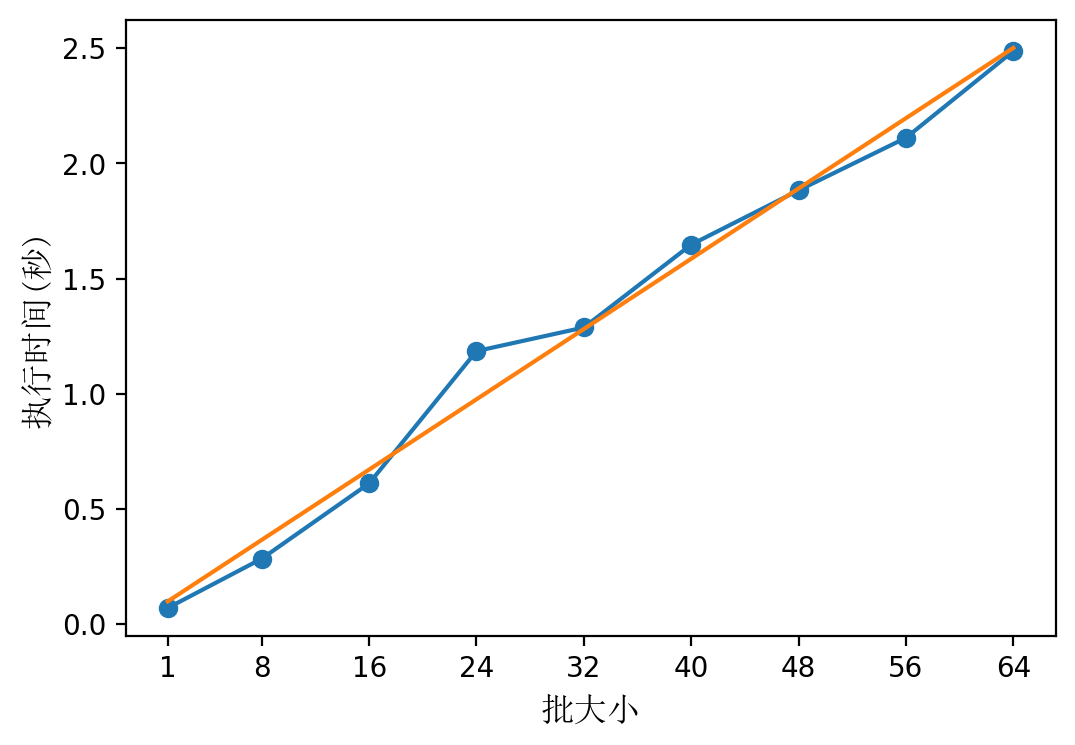

In [12]:
cpu_time_history = get_data("cpu")
plot(cpu_time_history)

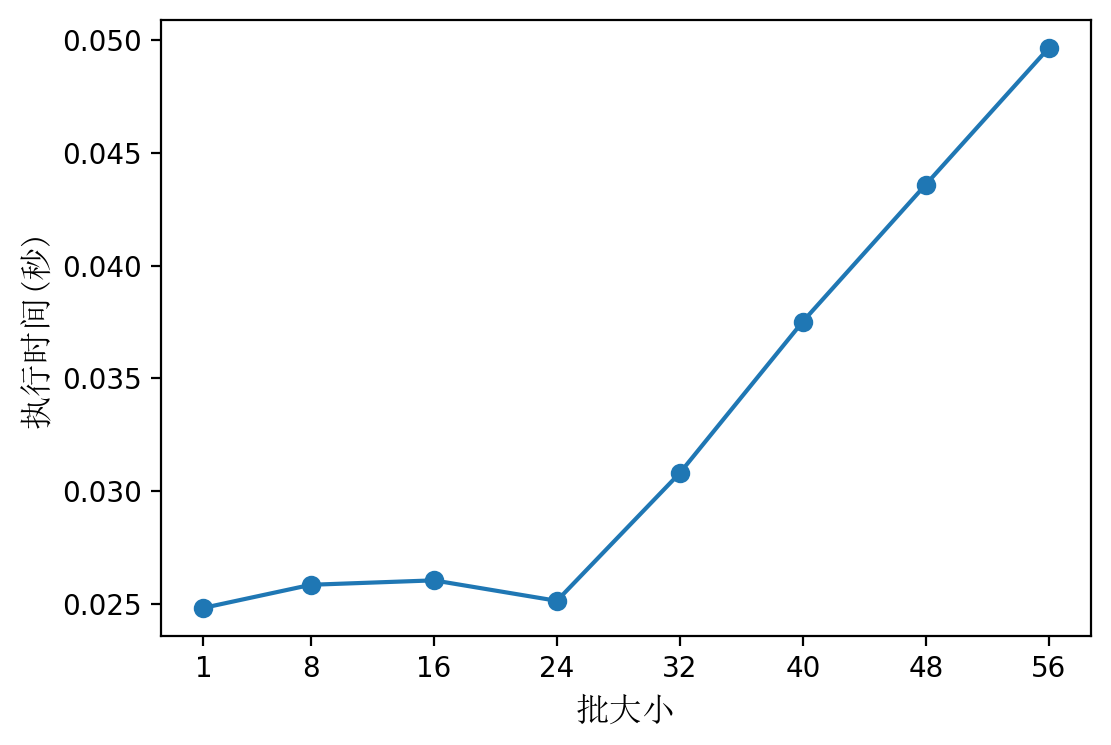

In [5]:
gpu_time_history = get_data("gpu")
plot(gpu_time_history)

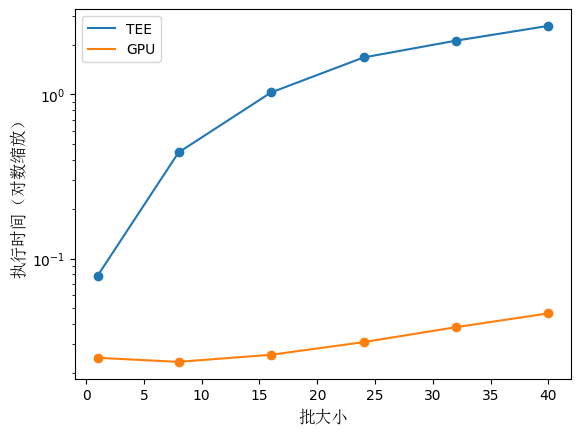

In [6]:
from numpy import mean


def plot():
    cpu_time_history = get_data("cpu")
    gpu_time_history = get_data("gpu")

    for k in sorted(np.linspace(13, 13, 1, dtype=int), reverse=True):
        x = []
        y1 = []
        y2 = []
        for bsz in np.linspace(1, 40, 6, dtype=int):
            datas = cpu_time_history
            if bsz in datas and k in datas[bsz]:
                x.append(bsz)
                data = datas[bsz][k]["DECODER_TIMER_CLEAR"]
                data = mean(data)
                y1.append(data)

            datas = gpu_time_history
            if bsz in datas and k in datas[bsz]:
                data = datas[bsz][k]["DECODER_TIMER_CLEAR"]
                data = mean(data)
                y2.append(data)

    # y1 = np.array(y1)
    # y2 = np.array(y2)
    # print(y1)
    # print(y2)
    # y1 = (y1 - y1.min()) / (y1.max() - y1.min())
    # y2 = (y2 - y2.min()) / (y2.max() - y2.min())
    plt.yscale('log') 
    plt.plot(x, y1, label="TEE")
    plt.scatter(x, y1)
    plt.plot(x, y2, label="GPU")
    plt.scatter(x, y2)

    plt.ylabel("执行时间（对数缩放）", fontproperties=font)
    plt.xlabel("批大小", fontproperties=font)
    plt.legend()


plot()